In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import sys
import os
file_path = 'D:\\GitHub\\DataIO\\'
sys.path.append(os.path.dirname(file_path))

from data_io import toleos_den

In [40]:
import orekit_jpype as orekit


orekit.initVM(jvmpath="C://Program Files//Eclipse Adoptium//jdk-17.0.18.8-hotspot//bin//server//jvm.dll",
              additional_classpaths=[r"D:\GitHub\contigo_edr\java_src\target\orekit_utils-1.0.0.jar"])

In [41]:
from orekit_jpype.pyhelpers import setup_orekit_data, download_orekit_data_curdir
#download_orekit_data_curdir()
setup_orekit_data(from_pip_library=False)

In [42]:
import pandas as pd
import numpy as np
import glob
import os
import sys

import matplotlib.pyplot as plt

from contigo.contigo_utils.utils import df_sp3

from contigo.constellation import Constellation
from contigo.edr_efd import EDRDensity

# Ephemeris
from contigo.ephemeris.orekit_ephem import OrekitEphem
from contigo.solar_system_ephem import SolarSystemEnvironment

# Forces and acceleration
from contigo.forces.third_body_acc import ThirdBodyEnv
from contigo.forces.grav_pot import EarthPotential
from contigo.forces.srp_orekit import SRPOrekitCB

In [43]:
import cdflib
def sw_scdyn(sat: str='B', 
                sdate='2010-01-01',
                nd: int=1,
                edate=None,
                local_dir='D:/data/SatDensities/SWARM/',
                full=False):
    
    # check to make sure appropriate satellites are loaded
    sat_opts = ['A', 'B', 'C']
    sat = sat.upper()
    if sat not in sat_opts: 
        raise ValueError("Invalid sat type. Expected one of: %s" % sat_opts)
    
    freq='D'
    # create a list of dates for
    # files to retrieved
    if edate is not None:
        d_ser = pd.date_range(start=pd.to_datetime(sdate), 
                              end=pd.to_datetime(edate),
                              freq=freq)
    else:
        d_ser = pd.date_range(start=sdate, periods=nd, freq=freq)
        edate = d_ser.max()
    
    fx = [
        os.path.join(local_dir, f'SW{sat}','xDYN',
                     f'SW*_{x.year}{x.month:02}{x.day:02}T*.cdf') 
        for x in d_ser
        ]
    
    fn = [glob.glob(x)[0] for x in fx if len(glob.glob(x)) > 0]
    
    a_head = []
    m_sc = []

    cdf_dat = {}
    cdf_att = {}

    for fi in fn:
        with cdflib.CDF(fi) as cdf_file:
            a_head.extend(cdf_file.varget('A_head'))
            m_sc.extend(cdf_file.varget('m_SC')) 
            if full:
                # loop through and save the variables
                for var in cdf_file.cdf_info().zVariables:
                    # Varibles
                    if var in cdf_dat:
                        cdf_dat[var].extend(cdf_file.varget(var))
                    else:
                        cdf_dat[var] = []
                        cdf_dat[var].extend(cdf_file.varget(var))
                        cdf_att[f'{var}_att'] = cdf_file.varattsget(var) 
                    


    if full:
        cdf_dat['DateTime'] = cdflib.epochs.CDFepoch.to_datetime(cdf_dat['Timestamp'])
        return cdf_dat, cdf_att
    else:
        return np.array(a_head), np.array(m_sc)

In [44]:
data_dir = r'D:\data\SatDensities\SWARM\SWB\SP3xCOM' 
fn_pre = 'SW_OPER_SP3BCOM_2__'

sdate = '2018-03-17' 
edate = '2018-03-29'
#edate = '2018-03-18'

dt_ran = pd.date_range(sdate,edate,freq='1D')

fn =  []

_ = [fn.extend(glob.glob(os.path.join(data_dir,f'{fn_pre}{dt.strftime("%Y%m%d")}*'))) for dt in dt_ran]


### Read in the state and kinematic data

Satellite state

Drag Area

In [45]:
sw_state = [df_sp3(f) for f in fn]
sw_state = pd.concat(sw_state,ignore_index=True)

dat, att = sw_scdyn(sdate=sdate,edate='2018-03-31', full=True)
kin_df = pd.DataFrame({'DateTime':pd.to_datetime(dat['DateTime']),
                       'area_head':np.linalg.norm(dat['A_head'],axis=1),
                       'sc_mass':dat['m_SC'], 
                       'srp_acc_sw':np.linalg.norm(dat['a_Sun'],axis=1)})

# combine the data
sw_state = pd.merge_asof(sw_state,kin_df,left_on='time', right_on='DateTime',
                         tolerance=pd.Timedelta('5s'))


In [46]:
sw_state.shape

(112320, 12)

In [47]:
sw_tol, sw_meta, _ = toleos_den.load_toleos(sat='SB',sdate=sdate, edate='2018-03-31')
sw_tol['dens_x_km'] = sw_tol['dens_x']*(1000.**3)

In [48]:
sw_state['cd'] = 3.7
sw_state['cr'] = 1.14
sw_state['srp_area'] = 2.5
sw_state['id'] = 'SW_dA'
sw_state['v2'] = np.linalg.norm(sw_state[['vx','vy','vz']].to_numpy(),axis=1)
sw_state['xy2'] = sw_state['x']**2+sw_state['y']**2


<Axes: xlabel='DateTime'>

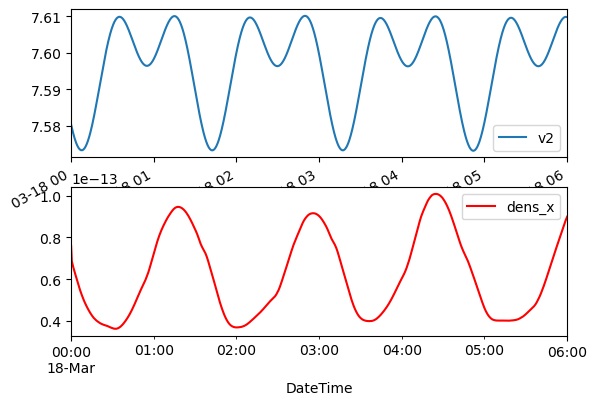

In [49]:
p1 = pd.to_datetime('2018-03-18 00:00:00')
p2 = p1 + pd.Timedelta('360min')

gd_st = (sw_state['DateTime'] >= p1) & (sw_state['DateTime'] <= p2)
gd_to = (sw_tol['DateTime'] >= p1) & (sw_tol['DateTime'] <= p2)

fig, ax = plt.subplots(2,1)

sw_state[gd_st].plot(x='DateTime',y='v2',ax=ax[0], xlim=[p1,p2])
sw_tol[gd_to].plot(x='DateTime',y='dens_x',ax=ax[1], color='r', xlim=[p1,p2])


In [50]:
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel
from org.orekit.utils import IERSConventions
from org.orekit.frames import FramesFactory
from org.orekit.time import AbsoluteDate, TimeScalesFactory

from org.hipparchus.geometry.euclidean.threed import Vector3D

lmax=70
utc = TimeScalesFactory.getGPS()
gravityProvider = GravityFieldFactory.getNormalizedProvider(lmax, lmax)
gravityfield = HolmesFeatherstoneAttractionModel(
    FramesFactory.getITRF(IERSConventions.IERS_2010, False), gravityProvider)


# setup the orekit vectors we need
pos_ecef = [Vector3D(x*1000., y*1000., z*1000.)
            for x, y, z in
            zip(sw_state['x'], sw_state['y'], sw_state['z'])]

epoch = [AbsoluteDate(dt.year, dt.month, dt.day, dt.hour, dt.minute, float(dt.second), utc)
          for dt in sw_state['time']]

# get the gravity potential at each spacecraft location
grav_pot = [gravityfield.value(ed, pos_v, 0.3986004415E+15)
            for ed, pos_v in
            zip(epoch, pos_ecef)]

grav_pot = np.array(grav_pot)

In [51]:
# create a Constellation object from the ESA POD file
# and calculate thirdbody acceleration from ThirdBody
hdf_sc1 = Constellation(state_file=fn, sc_id_input='SWB', tscale_input='GPS',
                    sc_mass=4.31e+02, cr=1.14, srp_area=2.5, cd=3.7, drag_area=1.1)

hdf_sc2 = Constellation(state=sw_state[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=sw_state['time'].to_numpy(), 
                        cd=sw_state['cd'].to_numpy(),
                        drag_area=sw_state['area_head'].to_numpy(),
                        sc_mass=sw_state['sc_mass'].to_numpy(),
                        cr=sw_state['cr'].to_numpy(),
                        srp_area=sw_state['srp_area'].to_numpy(), 
                        sc_id_input=sw_state['id'], 
                        tscale_input='GPS')

#step = 60
#id2 = hdf_sc1['SWB'].sc_id[::step]
#id2[:] = 'SWB2' 
#hdf_sc2 = Constellation(state=hdf_sc1['SWB'].state[::step,:],time= hdf_sc1['SWB'].sc_utc[::step],
#                        sc_id_input=hdf_sc1['SWB'].sc_id[::step], tscale_input='UTC',
#                        sc_mass=4.31e+02, cr=1.14, srp_area=2.5*2, cd=3.7, drag_area=1.1)

hdf_sc = hdf_sc1+hdf_sc2

In [52]:
hdf_sc

Constellation(n_spacecraft=2, ids=['SWB', 'SW_dA'])

In [53]:
# setup the ephemeris provider we want
# and the solar system environement 
# which defines the tolerance for ephemeris cacheing and the bodies we want
# in our solar system
ephem = OrekitEphem( )

env = SolarSystemEnvironment(bodies=['SUN','MOON'], tolerance=0.01, provider=ephem, 
                            ephem_time=hdf_sc.sspice_et, 
                            gps_time=hdf_sc.sspice_gps,
                            utc_time=hdf_sc.sc_utc)

In [54]:
# this is a big lmax but this is what 
# we use in the orekit derivation and
# is what we need here to for a comparison
ep = EarthPotential(lmax=100) 
tba_env = ThirdBodyEnv( )
srp = SRPOrekitCB( )

In [55]:
edr = EDRDensity(constellation=hdf_sc,
                 solarsys_env=env, 
                 force_models=[tba_env,srp],
                 potential_model=ep)

In [56]:
acc_con = edr.compute_edr()
den_con = edr.compute_denom()

ThirdBodyAcceleration
SRPOrekitCannonball
ThirdBodyAcceleration
SRPOrekitCannonball


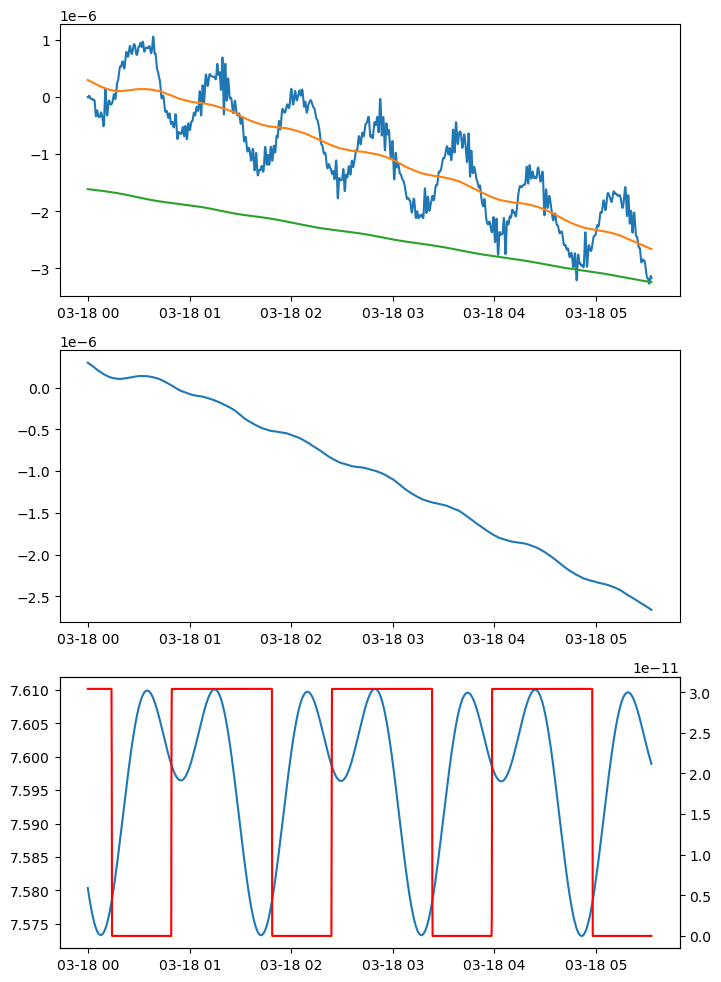

In [57]:
test = pd.DataFrame({'edr':acc_con['SWB']['edr']})
test['rolling_1'] = test['edr'].rolling(int(10*60*10/10), min_periods=1, center=True).mean()
test['rolling_2'] = test['edr'].rolling(int(90*60*10/10), min_periods=1, center=True).mean()

npts = 2000
fix, ax = plt.subplots(3,1,figsize=(8,12))
ax[0].plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
ax[0].plot(edr.constellation['SWB'].sc_utc[0:npts],test['rolling_1'].to_numpy()[0:npts])
ax[0].plot(edr.constellation['SWB'].sc_utc[0:npts],test['rolling_2'].to_numpy()[0:npts])

ax[1].plot(edr.constellation['SWB'].sc_utc[0:npts],test['rolling_1'].to_numpy()[0:npts])

ax[2].plot(edr.constellation['SWB'].sc_utc[0:npts],sw_state['v2'].to_numpy()[0:npts])
axt = ax[2].twinx()
axt.plot(edr.constellation['SWB'].sc_utc[0:npts],np.linalg.norm(edr.accelerations['SRPOrekitCannonball']['SW_dA'],axis=1)[0:npts], color='r')



In [58]:
from itertools import groupby
from operator import itemgetter
ns = np.where(np.linalg.norm(edr.accelerations['SRPOrekitCannonball']['SW_dA'],axis=1) == 0)
ns_group = []
for k, g in groupby(enumerate(ns[0]), lambda x: x[0] - x[1]):
        ns_group.append(list(map(itemgetter(1), g)))

ds = np.where(np.linalg.norm(edr.accelerations['SRPOrekitCannonball']['SW_dA'],axis=1) > 0)
ds_group = []
for k, g in groupby(enumerate(ds[0]), lambda x: x[0] - x[1]):
        ds_group.append(list(map(itemgetter(1), g)))

In [59]:
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

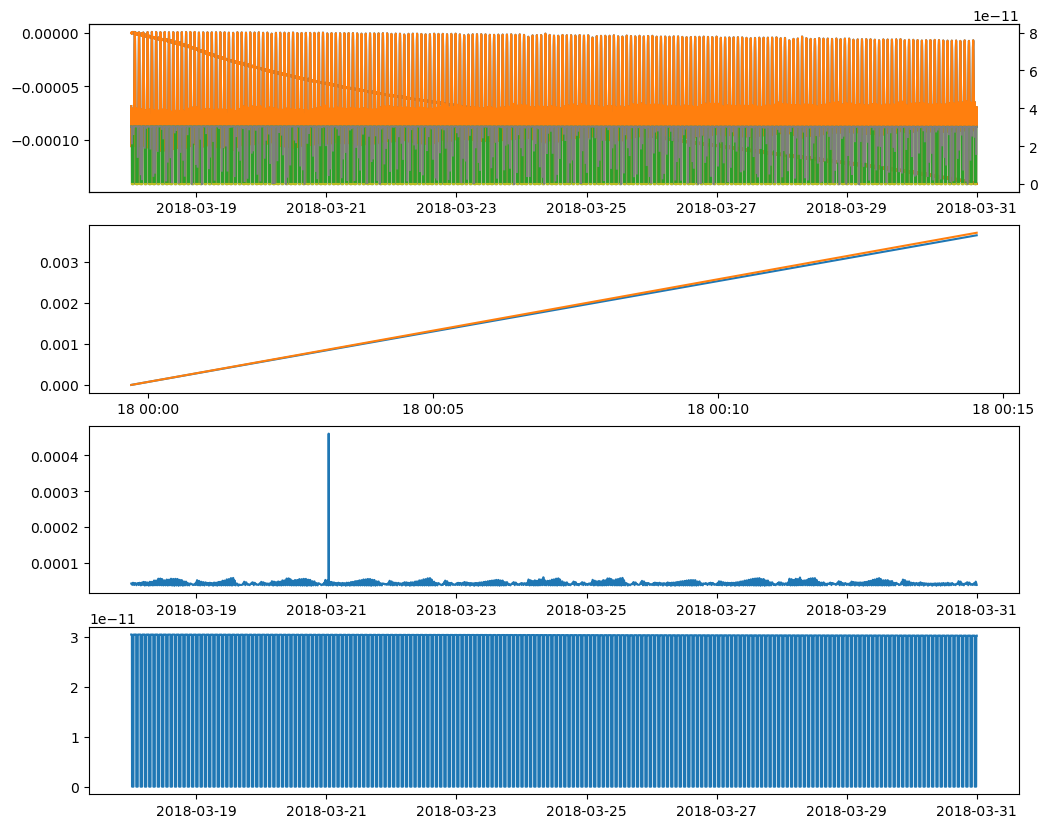

In [60]:
fig, ax = plt.subplots(4,1, figsize=(12,10))

orb=5
npts = int(5*90*60/10)
npts2 = int(npts)
npts = edr.constellation['SWB'].sc_utc.shape[0]
npts2 = npts


ax[0].plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
ax[0].plot(edr.constellation['SW_dA'].sc_utc[0:npts],acc_con['SW_dA']['edr'][0:npts])

#axt1 = ax[0].twinx()
axt2 = ax[0].twinx()
#axt2.plot(edr.constellation['SW_dA'].sc_utc[0:npts2-1],edr.e_gp['SW_dA'][0:npts2-1])
#axt2.plot(edr.constellation['SW_dA'].sc_utc[0:npts2-1],grav_pot[0:npts2-1]/1000**2)
#axt1.plot(edr.constellation['SW_dA'].sc_utc[0:npts-1],den_con['SW_dA'][1:npts]-den_con['SW_dA'][0:npts-1])
axt2.plot(edr.constellation['SW_dA'].sc_utc[0:npts-1],sw_state['srp_acc_sw'].to_numpy()[0:npts-1]/1000.)
axt2.plot(edr.constellation['SW_dA'].sc_utc[0:npts2-1],sw_state['srp_acc_sw'].to_numpy()[0:npts2-1]/1000.)
axt2.plot(edr.constellation['SW_dA'].sc_utc[0:npts-1],np.linalg.norm(edr.accelerations['SRPOrekitCannonball']['SW_dA'],axis=1)[0:npts-1])

for pts in ns_group:
    axt2.plot(edr.constellation['SW_dA'].sc_utc[pts],np.linalg.norm(edr.accelerations['SRPOrekitCannonball']['SW_dA'],axis=1)[pts],color=default_colors[-2])

for pts in ds_group:
    axt2.plot(edr.constellation['SW_dA'].sc_utc[pts],np.linalg.norm(edr.accelerations['SRPOrekitCannonball']['SW_dA'],axis=1)[pts],color=default_colors[-3])

ax[1].plot(edr.constellation['SWB'].sc_utc[0:90],den_con['SWB'][0:90])
ax[1].plot(edr.constellation['SW_dA'].sc_utc[0:90],den_con['SW_dA'][0:90])
#ax[1].plot(edr.constellation['SW_dA'].sc_utc[0:npts],acc_con['SW_dA']['edr'][0:npts]/den_con['SW_dA'][0:npts])

#ax[2].plot(edr.constellation['SWB'].sc_utc[0:npts-1],den_con['SWB'][1:npts]-den_con['SWB'][0:npts-1])
ax[2].plot(edr.constellation['SW_dA'].sc_utc[0:npts-1],den_con['SW_dA'][1:npts]-den_con['SW_dA'][0:npts-1])

ax[3].plot(edr.constellation['SW_dA'].sc_utc[0:npts-1],np.linalg.norm(edr.accelerations['SRPOrekitCannonball']['SW_dA'],axis=1)[0:npts-1])

In [61]:
acc_con[sat_der]

NameError: name 'sat_der' is not defined

In [62]:
cd = ns_group + ds_group

In [63]:
len(ds_group)

199

In [64]:
len(cd)

397

In [65]:
from scipy.integrate import simpson

sat_der='SWB'

test = pd.DataFrame({'edr':acc_con['SWB']['edr']})
test['rolling_1'] = test['edr'].rolling(int(10*60*10/10), min_periods=1, center=True).mean()
edr_d = test['rolling_1'].to_numpy()

ds_dedr = []
ds_dden = []
ds_dtime = []

ns_dedr = []
ns_dden = []
ns_dtime = []

dstol_efd = []
nstol_efd = []

    
for pts in ns_group[1:-2]:
    id_min = np.array(pts).min()
    id_max = np.array(pts).max()

    #ns_dedr.append(acc_con[sat_der]['edr'][id_max]-acc_con[sat_der]['edr'][id_min])
    ns_dedr.append(edr_d[id_max]-edr_d[id_min])
    ns_dden.append(den_con[sat_der][id_max] - den_con[sat_der][id_min])
    ns_dtime.append(pd.to_datetime(edr.constellation[sat_der].sc_utc[pts]).mean())

    s = pd.to_datetime(edr.constellation[sat_der].sc_utc[pts[0]]).tz_localize(None)
    e = pd.to_datetime(edr.constellation[sat_der].sc_utc[pts[-1]]).tz_localize(None)
                       

    gd_ind = (sw_comb['DateTime'] >= s) & (sw_comb['DateTime'] < e)

    v = sw_comb.loc[gd_ind,'v'].to_numpy()
    d = sw_comb.loc[gd_ind,'dens_x_km'].to_numpy()

    x = sw_comb.loc[gd_ind,'DateTime']
    x = (x-x.min()).dt.total_seconds().to_numpy()
    
    nume = simpson(d*v**3,x)
    deno = simpson(v**3,x)

    nstol_efd.append(nume/deno)

for pts in ds_group[1:-1]:
    id_min = np.array(pts).min()
    id_max = np.array(pts).max()

    #ds_dedr.append(acc_con[sat_der]['edr'][id_max]-acc_con[sat_der]['edr'][id_min])
    ds_dedr.append(edr_d[id_max]-edr_d[id_min])
    ds_dden.append(den_con[sat_der][id_max] - den_con[sat_der][id_min])
    ds_dtime.append(pd.to_datetime(edr.constellation[sat_der].sc_utc[pts]).mean())

    s = pd.to_datetime(edr.constellation[sat_der].sc_utc[pts[0]]).tz_localize(None)
    e = pd.to_datetime(edr.constellation[sat_der].sc_utc[pts[-1]]).tz_localize(None)
                       

    gd_ind = (sw_comb['DateTime'] >= s) & (sw_comb['DateTime'] < e)

    v = sw_comb.loc[gd_ind,'v'].to_numpy()
    d = sw_comb.loc[gd_ind,'dens_x_km'].to_numpy()

    x = sw_comb.loc[gd_ind,'DateTime']
    x = (x-x.min()).dt.total_seconds().to_numpy()
    
    nume = simpson(d*v**3,x)
    deno = simpson(v**3,x)

    dstol_efd.append(nume/deno)


fig, ax = plt.subplots(1,1)
ax.plot(np.array(ds_dtime),-2*np.array(ds_dedr)/np.array(ds_dden), label='EDR Dayside')
ax.plot(np.array(ns_dtime),-2*np.array(ns_dedr)/np.array(ns_dden), label='EDR Nightside')
ax.plot(np.array(ns_dtime),np.array(nstol_efd), label = 'Toleos Nightside')
ax.plot(np.array(ds_dtime),np.array(dstol_efd), label = 'Toleos Dayside')

ax.legend()

NameError: name 'sw_comb' is not defined

269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269
269


<Axes: xlabel='DateTime'>

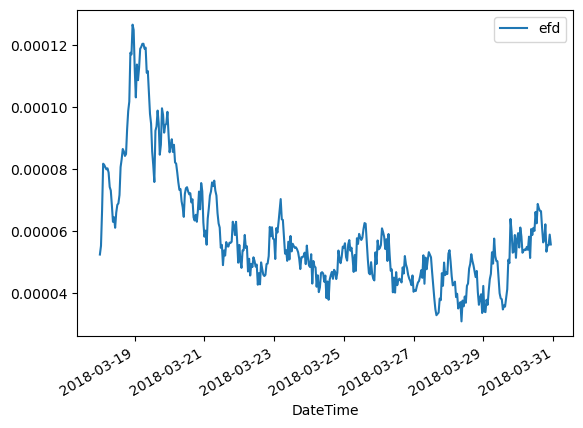

In [66]:
sat_der='SW_dA'
step = pd.Timedelta(minutes=45)
s = edr.constellation[sat_der].sc_utc[0]
e = s+step

delta_edr = []
delta_den = []
d_dt = []

edr_sw = pd.Series(acc_con[sat_der]['edr']).rolling(360, min_periods=1, center=True).mean().to_numpy()

while e < edr.constellation.sc_utc.max():
    gd_ind = np.where((edr.constellation[sat_der].sc_utc >= s) & (edr.constellation[sat_der].sc_utc < e))

    id_min = gd_ind[0].min() 
    id_max = gd_ind[0].max()

    print(id_max-id_min)

    delta_edr.append(edr_sw[id_max]-edr_sw[id_min])
    delta_den.append(den_con[sat_der][id_max] - den_con[sat_der][id_min])
    d_dt.append(s)

    s = s+step
    e = e+step

delta_edr = np.array(delta_edr)
delta_den = np.array(delta_den)
d_dt = np.array(d_dt)
efd = -2*delta_edr/delta_den

den_df = pd.DataFrame({'DateTime':d_dt, 'd_edr':delta_edr,'d_den':delta_den})
den_df['efd'] = -2*den_df['d_edr'].rolling(4, min_periods=1, center=True).mean()/den_df['d_den']

den_df['DateTime'] = den_df['DateTime'].dt.tz_localize(None)
den_df.plot(x='DateTime',y='efd')

In [67]:
col = ['dens_x_km','DateTime']

sw_state = pd.DataFrame({'DateTime':pd.to_datetime(hdf_sc['SWB'].sc_utc)})
sw_state['DateTime'] = sw_state['DateTime'].dt.tz_localize(None)
sw_state['vx'] = hdf_sc['SWB'].state_ecef[:,3]
sw_state['vy'] = hdf_sc['SWB'].state_ecef[:,4]
sw_state['vz'] = hdf_sc['SWB'].state_ecef[:,5]
sw_state['v'] = np.linalg.norm(hdf_sc['SWB'].state_ecef[:,3:],axis=1)

sw_comb = pd.merge_asof(sw_tol[col],sw_state, left_on='DateTime', right_on='DateTime',
                         tolerance=pd.Timedelta('15s')).dropna()

In [68]:
from scipy.integrate import simpson 

In [69]:
step = pd.Timedelta(minutes=90)
s = sw_comb['DateTime'].min()
e = s+step

tol_efd = []
tol_dt = []

while e < sw_comb['DateTime'].max():
    gd_ind = (sw_comb['DateTime'] >= s) & (sw_comb['DateTime'] < e)

    v = sw_comb.loc[gd_ind,'v'].to_numpy()
    d = sw_comb.loc[gd_ind,'dens_x_km'].to_numpy()

    x = sw_comb.loc[gd_ind,'DateTime']
    x = (x-x.min()).dt.total_seconds().to_numpy()
    
    nume = simpson(d*v**3,x)
    deno = simpson(v**3,x)

    tol_efd.append(nume/deno)
    tol_dt.append(s)

    s = s+step
    e = e+step

tol_efd = pd.DataFrame({'efd':tol_efd, 'DateTime':tol_dt})

In [70]:
import mplcyberpunk
plt.style.use("cyberpunk")

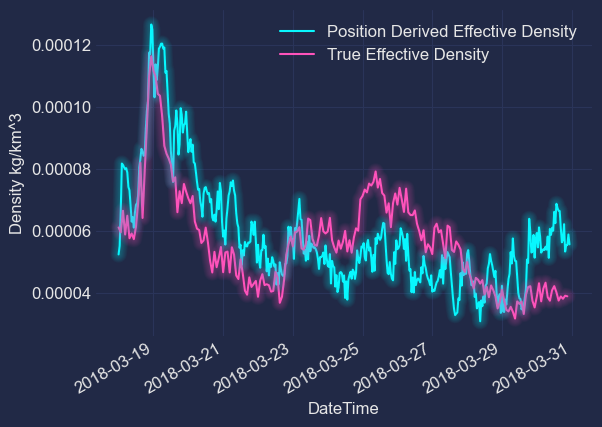

In [71]:
plt.rcParams.update({'font.size': 12})
ax = den_df.plot(x='DateTime',y='efd', label='Position Derived Effective Density',
                 ylabel='Density kg/km^3')
tol_efd.plot(x='DateTime',y='efd',ax=ax, label='True Effective Density')
mplcyberpunk.make_lines_glow(ax)


In [72]:
tol_efd = pd.merge_asof(tol_efd,den_df,left_on='DateTime',right_on='DateTime',
                        tolerance=pd.Timedelta('5m'))

In [73]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
from sklearn.metrics import r2_score

print(mean_absolute_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(median_absolute_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(mean_absolute_percentage_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(r2_score(tol_efd['efd_y'],tol_efd['efd_x']))

0.012284155693258237
0.012123975140753085
0.21626791609928417
0.4176108127600281


In [74]:
import cdflib
def sw_scdyn(sat: str='B', 
                sdate='2010-01-01',
                nd: int=1,
                edate=None,
                local_dir='D:/data/SatDensities/SWARM/',
                full=False):
    
    # check to make sure appropriate satellites are loaded
    sat_opts = ['A', 'B', 'C']
    sat = sat.upper()
    if sat not in sat_opts: 
        raise ValueError("Invalid sat type. Expected one of: %s" % sat_opts)
    
    freq='D'
    # create a list of dates for
    # files to retrieved
    if edate is not None:
        d_ser = pd.date_range(start=pd.to_datetime(sdate), 
                              end=pd.to_datetime(edate),
                              freq=freq)
    else:
        d_ser = pd.date_range(start=sdate, periods=nd, freq=freq)
        edate = d_ser.max()
    
    fx = [
        os.path.join(local_dir, f'SW{sat}','xDYN',
                     f'SW*_{x.year}{x.month:02}{x.day:02}T*.cdf') 
        for x in d_ser
        ]
    
    fn = [glob.glob(x)[0] for x in fx if len(glob.glob(x)) > 0]
    
    a_head = []
    m_sc = []

    cdf_dat = {}
    cdf_att = {}

    for fi in fn:
        with cdflib.CDF(fi) as cdf_file:
            a_head.extend(cdf_file.varget('A_head'))
            m_sc.extend(cdf_file.varget('m_SC')) 
            if full:
                # loop through and save the variables
                for var in cdf_file.cdf_info().zVariables:
                    # Varibles
                    if var in cdf_dat:
                        cdf_dat[var].extend(cdf_file.varget(var))
                    else:
                        cdf_dat[var] = []
                        cdf_dat[var].extend(cdf_file.varget(var))
                        cdf_att[f'{var}_att'] = cdf_file.varattsget(var) 
                    


    if full:
        cdf_dat['DateTime'] = cdflib.epochs.CDFepoch.to_datetime(cdf_dat['Timestamp'])
        return cdf_dat, cdf_att
    else:
        return np.array(a_head), np.array(m_sc)

In [75]:
dat, att = sw_scdyn(sdate=sdate,edate='2018-03-31', full=True)

In [76]:
srp_sw = np.linalg.norm(dat['a_Sun'],axis=1)


In [ ]:
srp_cont = SRPOrekitCB().acceleration(constellation=edr.constellation, solarsys_env=env)

In [ ]:
srp_acc = np.linalg.norm(srp_cont['SWB'],axis=1)

In [ ]:
sat = hdf_sc['SWB']

In [ ]:
edr_r = 0.5*sat.cd_arr*sat.drag_area_arr*(np.linalg.norm(sat.state_ecef[:,3:],axis=1)*1000)**3/sat.sc_mass_arr

In [ ]:

pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None).astype('datetime64[ns]')

In [ ]:
sc = slice(70000,75000)
s_st = pd.to_datetime(hdf_sc['SWB'].sc_utc[sc].min().replace(tzinfo=None) )
s_en = pd.to_datetime(hdf_sc['SWB'].sc_utc[sc].max().replace(tzinfo=None) )

#ax.plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
#ax.plot(edr.constellation['SWB2'].sc_utc[0:npts2],acc_con['SWB2']['edr'][0:npts2])

gd_swb = np.where((pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None) > s_st) & 
                  (pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None) < s_en)) 
gd_swb2 = np.where((pd.to_datetime(edr.constellation['SWB2'].sc_utc).tz_localize(None) > s_st) & 
                  (pd.to_datetime(edr.constellation['SWB2'].sc_utc).tz_localize(None) < s_en)) 
sw_gd = np.where((dat['DateTime'] > s_st) & (dat['DateTime'] < s_en))

fig, ax = plt.subplots(4,1, figsize=(10,10))
ax[0].plot(hdf_sc['SWB'].sc_utc[sc],srp_acc[sc])
ax[0].plot(dat['DateTime'][sw_gd],srp_sw[sw_gd]/1000.)

ax[1].plot(edr.constellation['SWB2'].sc_utc[gd_swb2],acc_con['SWB2']['edr'][gd_swb2])
ax[1].plot(edr.constellation['SWB'].sc_utc[gd_swb],acc_con['SWB']['edr'][gd_swb])

ax[2].plot(dat['DateTime'][sw_gd],np.linalg.norm(dat['A_head'],axis=1)[sw_gd])

ax[3].plot(hdf_sc['SWB'].sc_utc[sc],edr_r[sc])

In [ ]:
print(dat['DateTime'][0:5])
print(edr.constellation['SWB'].sc_utc[0:5])

In [ ]:
kin_df = pd.DataFrame({'DateTime':pd.to_datetime(dat['DateTime']),
                       'DragArea':np.linalg.norm(dat['A_head'],axis=1),
                       'SRP':srp_sw/1000.})
sc_df = pd.DataFrame({'DateTime':pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None)}).astype('datetime64[ns]')
sc_df['SRP_CB'] = srp_acc 

In [ ]:
sc_df = pd.merge_asof(sc_df,kin_df, left_on='DateTime',right_on='DateTime', 
                       tolerance=pd.Timedelta('5s'))

In [ ]:
print(sc_df.tail(3))
print(kin_df.tail(3))

In [ ]:
sc_df['SRP_ratio']=sc_df['SRP']/sc_df['SRP_CB']

In [ ]:
edr.constellation['SWB'].srp_area_arr

In [ ]:
sc_df['SRP_ratio'].to_numpy()

In [ ]:
hdf_sc1['SWB'].srp_area_arr

In [ ]:
edr.constellation['SWB'].srp_area_arr = sc_df['SRP_ratio'].to_numpy() * hdf_sc1['SWB'].srp_area_arr

In [ ]:
edr.constellation['SWB'].drag_area_arr = sc_df['DragArea'].to_numpy()           

In [ ]:
edr.constellation['SWB'].drag_area_arr[-1]

In [ ]:
acc_con = edr.compute_edr()
den_con = edr.compute_denom()

In [ ]:
den_con

In [ ]:
fig, ax = plt.subplots(2,1)

orb=5
npts = int(orb*90*60/10)
npts2 = int(npts/30)

ax[0].plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
ax[0].plot(edr.constellation['SWB2'].sc_utc[0:npts2],acc_con['SWB2']['edr'][0:npts2])
ax_t0 = ax[0].twinx()
ax_t0.plot(edr.constellation['SWB'].sc_utc[0:npts],den_con['SWB'][1:npts+1]-den_con['SWB'][0:npts]-den_con['SWB'][0])


ax[1].plot(edr.constellation['SWB'].sc_utc[0:npts],den_con['SWB'][1:npts+1]-den_con['SWB'][0:npts]-den_con['SWB'][0])
ax_t = ax[1].twinx()
ax_t.plot(edr.constellation['SWB2'].sc_utc[0:npts2],den_con['SWB2'][1:npts2+1]-den_con['SWB2'][0:npts2]-den_con['SWB2'][0])

In [ ]:
sc = edr.constellation['SWB']

In [ ]:
b=sc.cd_arr*(sc.drag_area_arr/1000.**2)/sc.sc_mass_arr

In [ ]:
sc = slice(70000,75000)
s_st = pd.to_datetime(hdf_sc['SWB'].sc_utc[sc].min().replace(tzinfo=None) )
s_en = pd.to_datetime(hdf_sc['SWB'].sc_utc[sc].max().replace(tzinfo=None) )

#ax.plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
#ax.plot(edr.constellation['SWB2'].sc_utc[0:npts2],acc_con['SWB2']['edr'][0:npts2])

gd_swb = np.where((pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None) > s_st) & 
                  (pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None) < s_en)) 
gd_swb2 = np.where((pd.to_datetime(edr.constellation['SWB2'].sc_utc).tz_localize(None) > s_st) & 
                  (pd.to_datetime(edr.constellation['SWB2'].sc_utc).tz_localize(None) < s_en)) 
sw_gd = np.where((dat['DateTime'] > s_st) & (dat['DateTime'] < s_en))

fig, ax = plt.subplots(5,1, figsize=(10,10))
ax[0].plot(hdf_sc['SWB'].sc_utc[sc],srp_acc[sc])
ax[0].plot(dat['DateTime'][sw_gd],srp_sw[sw_gd]/1000.)

ax[1].plot(edr.constellation['SWB2'].sc_utc[gd_swb2],acc_con['SWB2']['edr'][gd_swb2])
#ax[1].plot(edr.constellation['SWB'].sc_utc[gd_swb],acc_con['SWB']['edr'][gd_swb])
axt = ax[1].twinx()
axt.plot(dat['DateTime'][sw_gd],srp_sw[sw_gd]/1000.)

ax[2].plot(dat['DateTime'][sw_gd],np.linalg.norm(dat['A_head'],axis=1)[sw_gd])

ax[3].plot(hdf_sc['SWB'].sc_utc[gd_swb],b[gd_swb])

ax[4].plot(hdf_sc['SWB'].sc_utc[gd_swb],-2*acc_con['SWB']['edr'][gd_swb]/den_con['SWB'][gd_swb])

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
dat = pd.read_csv(r"C:\Users\murph\Desktop\2025-11-07_STARLINK-11081_catid_60405_trva.csv")

In [ ]:
dat['v'] = np.linalg.norm(dat[['v_ecef_x','v_ecef_y','v_ecef_z']],axis=1)

In [ ]:
dat['v'].plot()

In [ ]:
dat.columns

In [ ]:
ax = dat['v'].plot()
axt = ax.twinx() 
dat[['drag_area']].plot(ax=axt, color='red')

In [ ]:
r.text